In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=42)

In [31]:
X.shape, y.shape

((100, 1), (100,))

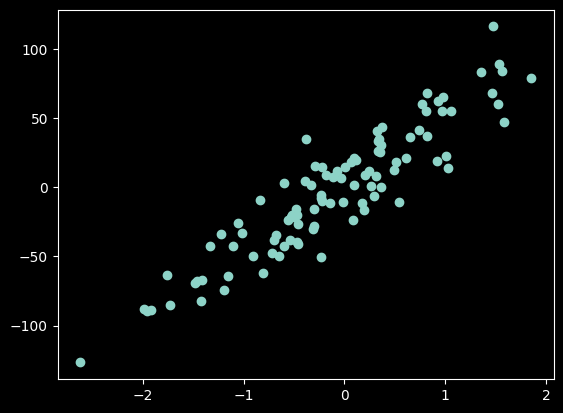

In [3]:
plt.scatter(X, y)

## Using SKLEARN

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [6]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_preds = lr.predict(X_test)

In [34]:
y_preds

array([-61.89061944,  69.2859475 ,  38.18180355, -18.13153892,
       -10.7475852 , -13.4374403 , -21.57314731, -82.21885915,
        38.62013778,  43.73324201,  48.39485129,  16.89248009,
       -56.87265598, -24.56639567, -53.60735619, -22.20164017,
        45.80251003,  11.50951861,  34.7197366 ,  17.76129888])

In [35]:
lr.coef_, lr.intercept_

(array([46.747264]), np.float64(0.19844442845175525))

In [36]:
from sklearn.metrics import r2_score

r2_score(y_test, y_preds)

0.8019015156159199

## Using Custom Gradient Regressor

In [39]:
class GradientDescentRegressor:
    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
        self.m = 0.0
        self.b = 0.0
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        X = X.ravel()
        y = y.ravel()
        n = len(X)

        for _ in range(self.epochs):
            y_pred = self.m*X + self.b
            error = y - y_pred

            slope_b = (-2/n) * np.sum(error)
            slope_m = (-2/n) * np.sum(error*X)

            self.b -= self.lr * slope_b
            self.m -= self.lr * slope_m

        return self

    def predict(self, X):
        X = X.ravel()
        return self.m*X + self.b

In [45]:
gdr = GradientDescentRegressor(learning_rate=0.01, epochs=1000)

In [46]:
gdr.fit(X_train, y_train)

In [50]:
gdr.m, gdr.b

(np.float64(46.74725659779171), np.float64(0.19844040212706793))

In [51]:
y_preds = gdr.predict(X_test)

In [52]:
r2_score(y_test, y_preds)

0.8019014721445831